RQ1: Can introducing semantically valid, artificially crafted, and maliciously altered network flow perturbations, creating the effects of a network poisoning attack, into an IDS training dataset, such as the Unified Multimodal NIDS CIC-IDS2019 dataset, reduce the robustness of the training of the model?

H10: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s training dataset has no statistically significant effect on the model's overall performance.

H1a: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s training dataset has a statistically significant effect on the model's overall performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
N_BOOTSTRAPS = 500
DECISION_THRESHOLD = 0.7
N_TSNE = 500
rng_tsne = np.random.default_rng(42)

In [3]:
df_sample = pd.read_csv("data/clean_sample_150000.csv")

In [4]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))

In [5]:
def base_xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric="mlogloss", random_state=42, tree_method="hist")

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_test = y_test.reset_index(drop=True).to_numpy()
model = base_xgb()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [7]:
def predict_benign_threshold(model, X, benign_threshold):
    proba = model.predict_proba(X)
    attack_pred = np.argmax(proba[:, 1:], axis=1) + 1
    return np.where(proba[:, 0] >= benign_threshold, 0, attack_pred)

In [8]:
proba_train = model.predict_proba(X_train)
y_train_arr = y_train.reset_index(drop=True).to_numpy()
attack_mask = y_train_arr != 0
atk_idx = np.where(attack_mask)[0]
atk_X = X_train.reset_index(drop=True).iloc[atk_idx]
atk_y = y_train_arr[atk_idx]
atk_proba = proba_train[atk_idx]
true_class_conf = atk_proba[np.arange(len(atk_y)), atk_y]
order = np.argsort(true_class_conf)
boundary_X = atk_X.iloc[order].reset_index(drop=True)
boundary_y = atk_y[order]
boundary_conf = true_class_conf[order]
boundary_df = boundary_X.copy()
boundary_df["true_label"] = boundary_y
boundary_df["confidence"] = boundary_conf
boundary_df.to_csv("boundary_attacks.csv", index=False)
print(f"Saved {len(boundary_df)} boundary-adjacent attack samples")
print(f"Confidence range: {boundary_conf.min():.4f} – {boundary_conf.max():.4f}")
print(f"Bottom 10% confidence threshold: {np.percentile(boundary_conf, 10):.4f}")
print("\nAverage confidence by class:")
all_conf = proba_train[np.arange(len(y_train_arr)), y_train_arr]
for cls_val, cls_name in enumerate(le.classes_):
    cls_mask = y_train_arr == cls_val
    print(f"  {cls_name:<16}: avg={all_conf[cls_mask].mean():.4f}  (n={cls_mask.sum():,})")

Saved 80000 boundary-adjacent attack samples
Confidence range: 0.0487 – 0.9998
Bottom 10% confidence threshold: 0.4304

Average confidence by class:
  BENIGN          : avg=0.9998  (n=40,000)
  DoS_ATTACK      : avg=0.8152  (n=40,000)
  NON_DoS_ATTACK  : avg=0.8152  (n=40,000)


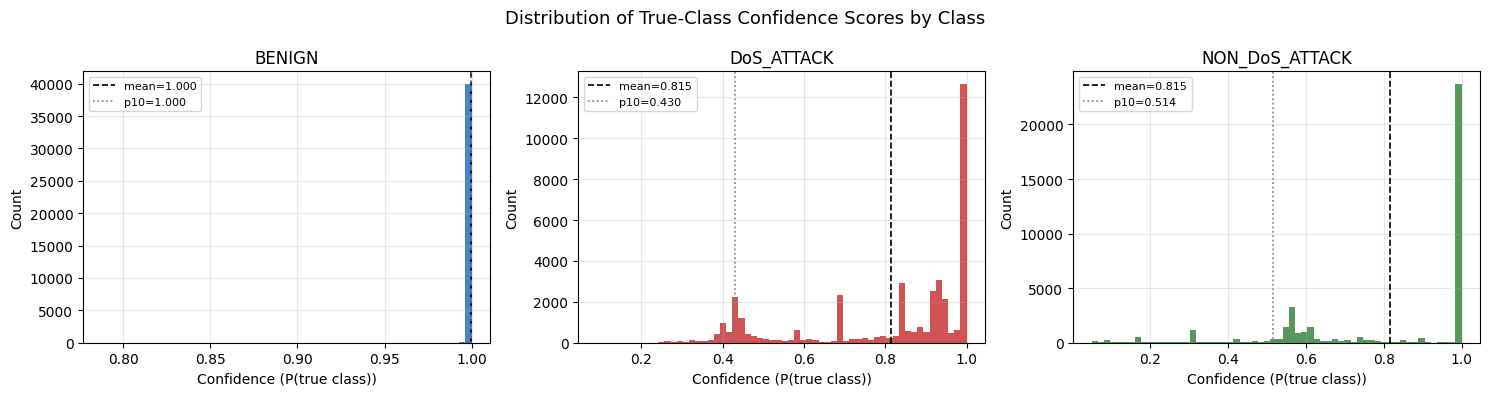

Saved confidence_distribution.png


In [9]:
cls_colors = ["#1565C0", "#C62828", "#2E7D32"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("Distribution of True-Class Confidence Scores by Class", fontsize=13)

for cls_val, cls_name in enumerate(le.classes_):
    cls_mask = y_train_arr == cls_val
    scores = all_conf[cls_mask]
    ax = axes[cls_val]
    ax.hist(scores, bins=60, color=cls_colors[cls_val], alpha=0.8, edgecolor="none")
    ax.axvline(scores.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"mean={scores.mean():.3f}")
    ax.axvline(np.percentile(scores, 10), color="grey", linestyle=":", linewidth=1.2,
               label=f"p10={np.percentile(scores, 10):.3f}")
    ax.set_title(cls_name)
    ax.set_xlabel("Confidence (P(true class))")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved confidence_distribution.png")

In [10]:
y_prob = model.predict_proba(X_test)
y_pred = predict_benign_threshold(model, X_test, DECISION_THRESHOLD)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.9070666666666667
Weighted F1: 0.9069017276411161
Macro F1: 0.9069017276411162
ROC-AUC: 0.9828945200000001


In [11]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.89      0.82      0.85     10000
NON_DoS_ATTACK       0.83      0.90      0.87     10000

      accuracy                           0.91     30000
     macro avg       0.91      0.91      0.91     30000
  weighted avg       0.91      0.91      0.91     30000



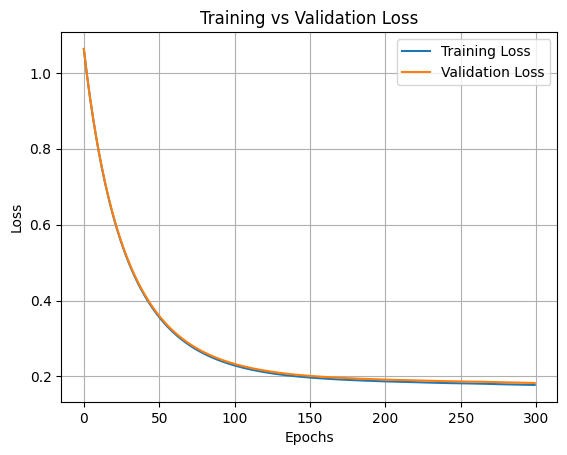

In [12]:
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']
plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [13]:
noise_df = pd.read_csv("data/noise_epsilon_0.05.csv")
noise_X = noise_df.drop(columns=["true_label","y_pred"], errors="ignore").select_dtypes(include=[np.number])
noise_X.replace([np.inf, -np.inf], np.nan, inplace=True)
noise_X.fillna(0, inplace=True)
noise_y = noise_df["true_label"].reset_index(drop=True).values
noise_X = noise_X.astype("float32")
noise_pred = predict_benign_threshold(model, noise_X, DECISION_THRESHOLD)
noise_prob = model.predict_proba(noise_X)
print("Accuracy:", accuracy_score(noise_y, noise_pred))
print("Weighted F1:", f1_score(noise_y, noise_pred, average='weighted'))
print("Macro F1:", f1_score(noise_y, noise_pred, average='macro'))

Accuracy: 0.28731942215088285
Weighted F1: 0.27679605673967106
Macro F1: 0.19410356252250394


In [14]:
present_labels = np.unique(np.concatenate([noise_y, noise_pred]))
print(classification_report(noise_y, noise_pred, target_names=le.classes_[present_labels]))

                precision    recall  f1-score   support

        BENIGN       0.00      0.00      0.00        51
    DoS_ATTACK       0.22      0.25      0.23       237
NON_DoS_ATTACK       0.34      0.36      0.35       335

      accuracy                           0.29       623
     macro avg       0.19      0.20      0.19       623
  weighted avg       0.27      0.29      0.28       623



In [15]:
adv_df = pd.read_csv("data/adversarial_epsilon_0.05.csv")
adv_X = adv_df.drop(columns=["true_label","pred_clean", "pred_adv"], errors="ignore").select_dtypes(include=[np.number])
adv_X.replace([np.inf, -np.inf], np.nan, inplace=True)
adv_X.fillna(0, inplace=True)
adv_y = adv_df["true_label"].reset_index(drop=True).values
adv_X = adv_X.astype("float32")
adv_pred = predict_benign_threshold(model, adv_X, DECISION_THRESHOLD)
adv_prob = model.predict_proba(adv_X)
print("Accuracy:", accuracy_score(adv_y, adv_pred))
print("Weighted F1:", f1_score(adv_y, adv_pred, average='weighted'))
print("Macro F1:", f1_score(adv_y, adv_pred, average='macro'))

Accuracy: 0.5374449339207048
Weighted F1: 0.5096990516939913
Macro F1: 0.5096990516939913


In [16]:
present_labels = np.unique(np.concatenate([adv_y, adv_pred]))
print(classification_report(adv_y, adv_pred, target_names=le.classes_[present_labels], zero_division=0))

                precision    recall  f1-score   support

    DoS_ATTACK       0.53      0.78      0.63       227
NON_DoS_ATTACK       0.57      0.30      0.39       227

      accuracy                           0.54       454
     macro avg       0.55      0.54      0.51       454
  weighted avg       0.55      0.54      0.51       454



In [17]:
hsj_df = pd.read_csv("data/adversarial_hsj_xgb.csv")
hsj_X = hsj_df.drop(columns=["true_label","pred_clean", "pred_adv"], errors="ignore").select_dtypes(include=[np.number])
hsj_X.replace([np.inf, -np.inf], np.nan, inplace=True)
hsj_X.fillna(0, inplace=True)
hsj_y = hsj_df["true_label"].reset_index(drop=True).values
hsj_X = hsj_X.astype("float32")
hsj_pred = predict_benign_threshold(model, hsj_X, DECISION_THRESHOLD)
hsj_prob = model.predict_proba(hsj_X)
print("Accuracy:", accuracy_score(hsj_y, hsj_pred))
print("Weighted F1:", f1_score(hsj_y, hsj_pred, average='weighted'))
print("Macro F1:", f1_score(hsj_y, hsj_pred, average='macro'))

Accuracy: 0.8511210762331839
Weighted F1: 0.9195736434108526
Macro F1: 0.30652454780361754


In [18]:
boundary_df = pd.read_csv("boundary_attacks.csv")
boundary_X = boundary_df.drop(columns=["true_label", "confidence"], errors="ignore").select_dtypes(include=[np.number])
boundary_X.replace([np.inf, -np.inf], np.nan, inplace=True)
boundary_X.fillna(0, inplace=True)
boundary_y = boundary_df["true_label"].reset_index(drop=True).values
boundary_X = boundary_X.astype("float32")
print(f"Boundary samples: {len(boundary_df)}, class distribution: {dict(zip(*np.unique(boundary_y, return_counts=True)))}")

Boundary samples: 80000, class distribution: {np.int64(1): np.int64(40000), np.int64(2): np.int64(40000)}


Running t-SNE on 2454 samples...


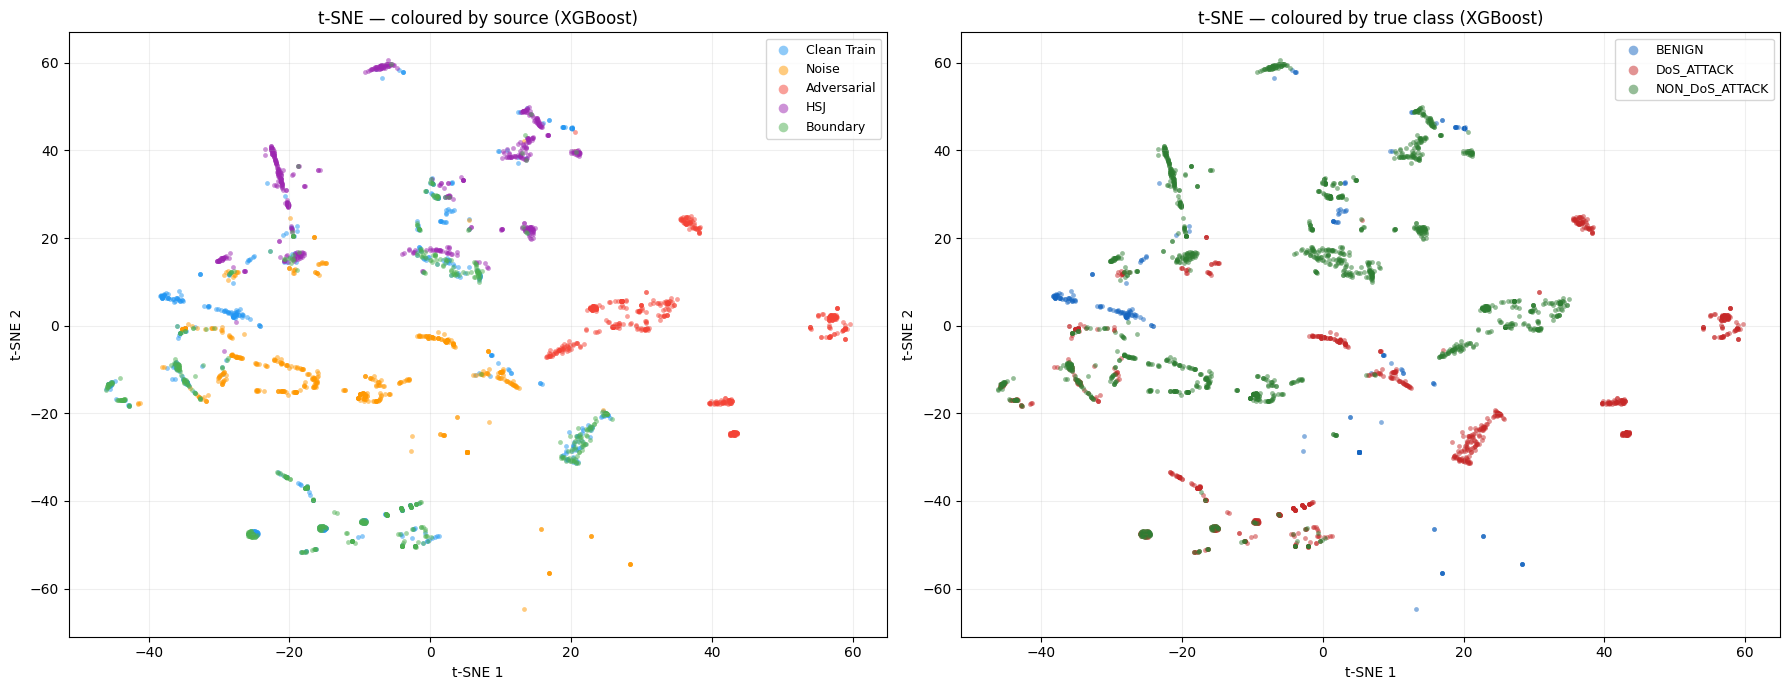

Saved tsne_xgboost.png


In [19]:
cols = X_train.columns.tolist()
sources_tsne = {
    "Clean Train": (X_train.reset_index(drop=True),   y_train.reset_index(drop=True).to_numpy()),
    "Noise":       (noise_X.reset_index(drop=True),    noise_y),
    "Adversarial": (adv_X.reset_index(drop=True),      adv_y),
    "HSJ":         (hsj_X.reset_index(drop=True),      hsj_y),
    "Boundary":    (boundary_X.reset_index(drop=True), boundary_y),
}

all_X_tsne, all_source, all_class = [], [], []
for src_name, (sx, sy) in sources_tsne.items():
    n = min(N_TSNE, len(sx))
    idx = rng_tsne.choice(len(sx), size=n, replace=False)
    sx_arr = sx[cols].values if hasattr(sx, "columns") else sx
    all_X_tsne.append(sx_arr[idx])
    all_source.extend([src_name] * n)
    all_class.extend(sy[idx].tolist())

all_X_tsne = np.vstack(all_X_tsne).astype(np.float32)
all_source  = np.array(all_source)
all_class   = np.array(all_class)

print(f"Running t-SNE on {len(all_X_tsne)} samples...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=-1)
Z = tsne.fit_transform(all_X_tsne)

src_order  = ["Clean Train", "Noise", "Adversarial", "HSJ", "Boundary"]
src_colors = {"Clean Train": "#2196F3", "Noise": "#FF9800", "Adversarial": "#F44336",
              "HSJ": "#9C27B0", "Boundary": "#4CAF50"}
cls_colors = {0: "#1565C0", 1: "#C62828", 2: "#2E7D32"}
cls_labels = {i: c for i, c in enumerate(le.classes_)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for src in src_order:
    mask = all_source == src
    ax.scatter(Z[mask, 0], Z[mask, 1], c=src_colors[src], label=src,
               alpha=0.5, s=12, linewidths=0)
ax.set_title("t-SNE — coloured by source (XGBoost)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
for cls in [0, 1, 2]:
    mask = all_class == cls
    ax.scatter(Z[mask, 0], Z[mask, 1], c=cls_colors[cls],
               label=cls_labels[cls], alpha=0.5, s=12, linewidths=0)
ax.set_title("t-SNE — coloured by true class (XGBoost)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("tsne_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved tsne_xgboost.png")

In [20]:
def poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate, ae_conf=None, random_state=42):
    ae_X = ae_X[X_train.columns]
    rng = np.random.default_rng(random_state)
    n_total = len(X_train)
    n_poison = int(n_total * poison_rate)
    X_clean = X_train.reset_index(drop=True).copy()
    y_clean = y_train.reset_index(drop=True).to_numpy().copy()
    if n_poison == 0:
        shuffle_idx = rng.permutation(n_total)
        return X_clean.iloc[shuffle_idx].reset_index(drop=True), y_clean[shuffle_idx]
    attack_mask = ae_y != 0
    ae_X_attacks = ae_X[attack_mask].reset_index(drop=True)
    n_pool = len(ae_X_attacks)
    if ae_conf is not None:
        conf_attacks = ae_conf[attack_mask]
        weights = 1.0 / (conf_attacks + 1e-6)   # lower confidence → higher selection weight
        weights = weights / weights.sum()
        chosen = rng.choice(n_pool, size=n_poison, replace=(n_poison > n_pool), p=weights)
    else:
        chosen = rng.choice(n_pool, size=n_poison, replace=(n_poison > n_pool))
    X_poison = ae_X_attacks.iloc[chosen].reset_index(drop=True).copy()
    y_poison = np.zeros(n_poison, dtype=int)
    keep_mask = np.ones(n_total, dtype=bool)
    attack_train_idx = np.where(y_clean != 0)[0]
    n_drop_attack = min(n_poison, len(attack_train_idx))
    atk_classes, atk_counts = np.unique(y_clean[attack_train_idx], return_counts=True)
    atk_fracs = atk_counts / atk_counts.sum()
    drop_per_cls = np.floor(atk_fracs * n_drop_attack).astype(int)
    remainder = n_drop_attack - drop_per_cls.sum()
    for k in np.argsort(-atk_fracs)[:remainder]:
        drop_per_cls[k] += 1
    for cls, n_drop in zip(atk_classes, drop_per_cls):
        cls_idx = np.where(y_clean == cls)[0]
        to_drop = rng.choice(cls_idx, size=min(n_drop, len(cls_idx)), replace=False)
        keep_mask[to_drop] = False
    if n_poison > len(attack_train_idx):
        extra = n_poison - len(attack_train_idx)
        benign_idx = np.where(y_clean == 0)[0]
        extra_drop = rng.choice(benign_idx, size=min(extra, len(benign_idx)), replace=False)
        keep_mask[extra_drop] = False
    keep_idx = np.where(keep_mask)[0]
    X_kept = X_clean.iloc[keep_idx].reset_index(drop=True)
    y_kept = y_clean[keep_idx]
    X_poisoned = pd.concat([X_kept, X_poison], ignore_index=True)
    y_poisoned = np.concatenate([y_kept, y_poison])
    shuffle_idx = rng.permutation(len(X_poisoned))
    return X_poisoned.iloc[shuffle_idx].reset_index(drop=True), y_poisoned[shuffle_idx]

In [21]:
def attack_miss_rate(y_true, y_pred):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    benign_idx = np.where(labels == 0)[0][0]
    missed   = cm[:, benign_idx].sum() - cm[benign_idx, benign_idx]
    n_attack = cm.sum() - cm[benign_idx].sum()
    detected = n_attack - missed
    return missed / (missed + detected + 1e-10)

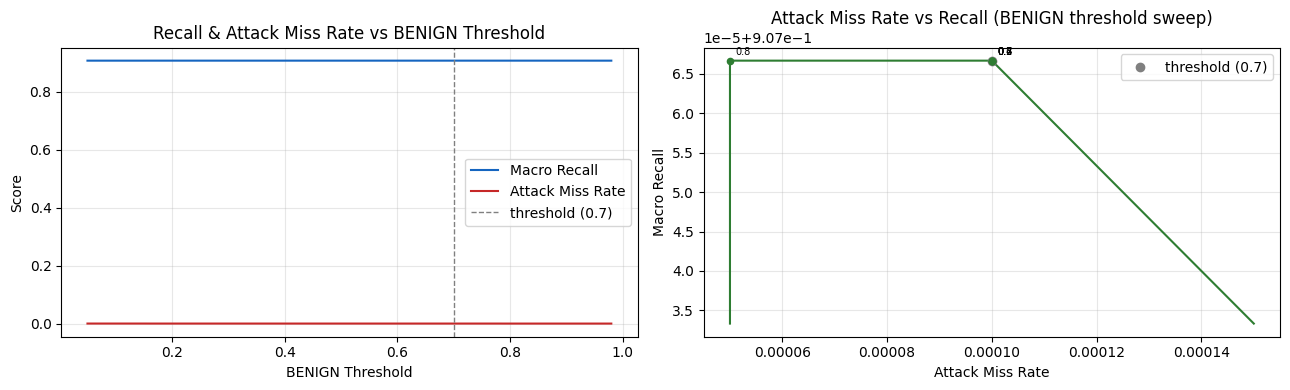

Saved threshold_sweep.png


In [22]:
thresholds = np.arange(0.05, 0.99, 0.01)
miss_rates, recalls = [], []
for t in thresholds:
    y_pred_t = predict_benign_threshold(model, X_test, t)
    miss_rates.append(attack_miss_rate(y_test, y_pred_t))
    recalls.append(recall_score(y_test, y_pred_t, average="macro", zero_division=0))
miss_rates, recalls = np.array(miss_rates), np.array(recalls)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(thresholds, recalls,    color="#1565C0", label="Macro Recall")
ax.plot(thresholds, miss_rates, color="#C62828", label="Attack Miss Rate")
ax.axvline(DECISION_THRESHOLD, color="grey", linestyle="--", linewidth=1, label=f"threshold ({DECISION_THRESHOLD})")
ax.set_xlabel("BENIGN Threshold")
ax.set_ylabel("Score")
ax.set_title("Recall & Attack Miss Rate vs BENIGN Threshold")
ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1]
ax.plot(miss_rates, recalls, color="#2E7D32", linewidth=1.5)
default_idx = np.argmin(np.abs(thresholds - DECISION_THRESHOLD))
ax.scatter(miss_rates[default_idx], recalls[default_idx], color="grey", zorder=5, label=f"threshold ({DECISION_THRESHOLD})")
for t_mark in [0.2, 0.3, 0.4, 0.6, 0.7, 0.8]:
    idx = np.argmin(np.abs(thresholds - t_mark))
    ax.annotate(f"{t_mark}", (miss_rates[idx], recalls[idx]), textcoords="offset points", xytext=(4, 4), fontsize=7)
    ax.scatter(miss_rates[idx], recalls[idx], s=20, color="#2E7D32", zorder=5)
ax.set_xlabel("Attack Miss Rate")
ax.set_ylabel("Macro Recall")
ax.set_title("Attack Miss Rate vs Recall (BENIGN threshold sweep)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved threshold_sweep.png")

In [23]:
def pool_confidence(model, X_pool, y_pool):
    """True-class confidence for each sample in an adversarial pool."""
    X_arr = X_pool.values if hasattr(X_pool, "values") else X_pool
    proba = model.predict_proba(X_arr.astype(np.float32))
    return proba[np.arange(len(y_pool)), y_pool]
noise_conf = pool_confidence(model, noise_X, noise_y)
adv_conf   = pool_confidence(model, adv_X,   adv_y)
hsj_conf   = pool_confidence(model, hsj_X,   hsj_y)
print("Pool true-class confidence (lower = more boundary-adjacent = higher poison weight):")
for name, conf, y in [("Noise",       noise_conf,    noise_y),
                       ("Adversarial", adv_conf,      adv_y),
                       ("HSJ",         hsj_conf,      hsj_y),
                       ("Boundary",    boundary_conf, boundary_y)]:
    atk_conf = conf[np.array(y) != 0]
    print(f"  {name:<12}: n={len(atk_conf):6,}  "
          f"mean={atk_conf.mean():.4f}  "
          f"p10={np.percentile(atk_conf,10):.4f}  "
          f"p90={np.percentile(atk_conf,90):.4f}")

Pool true-class confidence (lower = more boundary-adjacent = higher poison weight):
  Noise       : n=   572  mean=0.4362  p10=0.1915  p90=0.7940
  Adversarial : n=   454  mean=0.5534  p10=0.1988  p90=0.9449
  HSJ         : n= 1,115  mean=0.3682  p10=0.2224  p90=0.4900
  Boundary    : n=80,000  mean=0.8152  p10=0.4304  p90=0.9998


In [24]:
GROUPS = {
    "Control (0%)":      0.00,
    "Experiment 1 (5%)": 0.05,
    "Experiment 2 (10%)": 0.10,
    "Experiment 3 (15%)": 0.15,
    "Experiment 4 (20%)": 0.20,
    "Experiment 5 (25%)": 0.25,
    "Experiment 6 (30%)": 0.30,
    "Experiment 7 (35%)": 0.35,
    "Experiment 8 (40%)": 0.40,
    "Experiment 9 (45%)": 0.45,
    "Experiment 10 (50%)": 0.50
}

In [25]:
def ci(vals): return np.percentile(vals, 2.5), np.percentile(vals, 97.5)
all_results = {"Noise": [], "Adversarial": [], "HSJ": [], "Boundary": []}
group_preds = {"Noise": {}, "Adversarial": {}, "HSJ": {}, "Boundary": {}}
sources = [
    ("Noise",       noise_X,    noise_y,    noise_conf),
    ("Adversarial", adv_X,      adv_y,      adv_conf),
    ("HSJ",         hsj_X,      hsj_y,      hsj_conf),
    ("Boundary",    boundary_X, boundary_y, boundary_conf)]
for source_name, ae_X, ae_y, ae_conf in sources:
    for group_name, poison_rate in GROUPS.items():
        print(f"[{source_name}] {group_name} ...", end=" ", flush=True)
        X_tr, y_tr = poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate, ae_conf=ae_conf)
        exp_model = base_xgb()
        exp_model.fit(X_tr, y_tr)
        y_pred     = predict_benign_threshold(exp_model, X_test, DECISION_THRESHOLD)
        y_prob_exp = exp_model.predict_proba(X_test)
        bootstrap_indices = [resample(np.arange(len(y_test)), replace=True) for _ in range(N_BOOTSTRAPS)]
        group_preds[source_name][group_name] = y_pred
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
        mac  = f1_score(y_test, y_pred, average="macro", zero_division=0)
        wt   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        miss = attack_miss_rate(y_test, y_pred)
        roc  = roc_auc_score(y_test, y_prob_exp, multi_class="ovr", average="weighted")
        acc_b, prec_b, rec_b, mac_b, wt_b, miss_b = [], [], [], [], [], []
        for idx in bootstrap_indices:
            acc_b.append(accuracy_score(y_test[idx], y_pred[idx]))
            prec_b.append(precision_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            rec_b.append(recall_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            mac_b.append(f1_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            wt_b.append(f1_score(y_test[idx], y_pred[idx], average="weighted", zero_division=0))
            miss_b.append(attack_miss_rate(y_test[idx], y_pred[idx]))
        all_results[source_name].append({
            "Group": group_name,
            "Poison Rate": poison_rate,
            "Accuracy": round(acc, 4),        "Acc CI": ci(acc_b),
            "Macro Precision": round(prec, 4), "Prec CI": ci(prec_b),
            "Macro Recall": round(rec, 4),     "Rec CI": ci(rec_b),
            "Macro F1": round(mac, 4),         "MacF1 CI": ci(mac_b),
            "Weighted F1": round(wt, 4),       "WtF1 CI": ci(wt_b),
            "Attack Miss Rate": round(miss, 4), "Miss CI": ci(miss_b),
            "ROC-AUC": round(roc, 4),
        })
        print(f"F1={mac:.4f}  Miss={miss:.4f}  AUC={roc:.4f}")

[Noise] Control (0%) ... F1=0.9067  Miss=0.0001  AUC=0.9829
[Noise] Experiment 1 (5%) ... F1=0.9075  Miss=0.0000  AUC=0.9831
[Noise] Experiment 2 (10%) ... F1=0.9072  Miss=0.0000  AUC=0.9829
[Noise] Experiment 3 (15%) ... F1=0.9061  Miss=0.0001  AUC=0.9827
[Noise] Experiment 4 (20%) ... F1=0.9060  Miss=0.0002  AUC=0.9828
[Noise] Experiment 5 (25%) ... F1=0.9062  Miss=0.0002  AUC=0.9827
[Noise] Experiment 6 (30%) ... F1=0.9053  Miss=0.0002  AUC=0.9823
[Noise] Experiment 7 (35%) ... F1=0.9047  Miss=0.0002  AUC=0.9823
[Noise] Experiment 8 (40%) ... F1=0.9072  Miss=0.0002  AUC=0.9826
[Noise] Experiment 9 (45%) ... F1=0.9055  Miss=0.0002  AUC=0.9825
[Noise] Experiment 10 (50%) ... F1=0.9036  Miss=0.0002  AUC=0.9821
[Adversarial] Control (0%) ... F1=0.9067  Miss=0.0001  AUC=0.9829
[Adversarial] Experiment 1 (5%) ... F1=0.9058  Miss=0.0001  AUC=0.9828
[Adversarial] Experiment 2 (10%) ... F1=0.9058  Miss=0.0001  AUC=0.9825
[Adversarial] Experiment 3 (15%) ... F1=0.9049  Miss=0.0001  AUC=0.9826

In [26]:
for source_name, results in all_results.items():
    ctrl = results[0]
    print(f"\n── {source_name}: effect sizes vs control ──")
    for r in results[1:]:
        dF1 = r['Macro F1'] - ctrl['Macro F1']
        tag = 'NEGLIGIBLE' if abs(dF1) < 0.01 else 'material'
        print(f"  {r['Group']:<18} ΔF1={dF1:+.4f} ({dF1/ctrl['Macro F1']:+.2%})  "
              f"ΔAttackMiss={r['Attack Miss Rate']-ctrl['Attack Miss Rate']:+.4f}  [{tag}]")

print("\n── Poison-pool diversity (caps what a 'high poison rate' means) ──")
for source_name, ae_X, ae_y, _ in sources:
    pool   = ae_X.values[ae_y != 0] if hasattr(ae_X, 'values') else ae_X[ae_y != 0]
    n_uniq = len(np.unique(pool, axis=0)); r50 = int(len(X_train) * 0.5)
    print(f"  {source_name:<12} {n_uniq:>5} unique attack vectors -> ~{r50/max(n_uniq,1):.0f}x duplication at 50%")


── Noise: effect sizes vs control ──
  Experiment 1 (5%)  ΔF1=+0.0008 (+0.09%)  ΔAttackMiss=-0.0001  [NEGLIGIBLE]
  Experiment 2 (10%) ΔF1=+0.0005 (+0.06%)  ΔAttackMiss=-0.0001  [NEGLIGIBLE]
  Experiment 3 (15%) ΔF1=-0.0006 (-0.07%)  ΔAttackMiss=+0.0000  [NEGLIGIBLE]
  Experiment 4 (20%) ΔF1=-0.0007 (-0.08%)  ΔAttackMiss=+0.0001  [NEGLIGIBLE]
  Experiment 5 (25%) ΔF1=-0.0005 (-0.06%)  ΔAttackMiss=+0.0001  [NEGLIGIBLE]
  Experiment 6 (30%) ΔF1=-0.0014 (-0.15%)  ΔAttackMiss=+0.0001  [NEGLIGIBLE]
  Experiment 7 (35%) ΔF1=-0.0020 (-0.22%)  ΔAttackMiss=+0.0001  [NEGLIGIBLE]
  Experiment 8 (40%) ΔF1=+0.0005 (+0.06%)  ΔAttackMiss=+0.0001  [NEGLIGIBLE]
  Experiment 9 (45%) ΔF1=-0.0012 (-0.13%)  ΔAttackMiss=+0.0001  [NEGLIGIBLE]
  Experiment 10 (50%) ΔF1=-0.0031 (-0.34%)  ΔAttackMiss=+0.0001  [NEGLIGIBLE]

── Adversarial: effect sizes vs control ──
  Experiment 1 (5%)  ΔF1=-0.0009 (-0.10%)  ΔAttackMiss=+0.0000  [NEGLIGIBLE]
  Experiment 2 (10%) ΔF1=-0.0009 (-0.10%)  ΔAttackMiss=+0.0000  [NEGLI

In [27]:
for source_name, results in all_results.items():
    print(f"\n\n══ {source_name.upper()} — SUMMARY WITH 95% BOOTSTRAP CIs ══")
    summary = pd.DataFrame([{
        "Group": r["Group"],
        "Poison Rate": f"{int(r['Poison Rate']*100)}%",
        "Accuracy":    f"{r['Accuracy']} [{r['Acc CI'][0]:.4f}, {r['Acc CI'][1]:.4f}]",
        "Macro Precision": f"{r['Macro Precision']} [{r['Prec CI'][0]:.4f}, {r['Prec CI'][1]:.4f}]",
        "Macro Recall": f"{r['Macro Recall']} [{r['Rec CI'][0]:.4f}, {r['Rec CI'][1]:.4f}]",
        "Macro F1":    f"{r['Macro F1']} [{r['MacF1 CI'][0]:.4f}, {r['MacF1 CI'][1]:.4f}]",
        "Weighted F1": f"{r['Weighted F1']} [{r['WtF1 CI'][0]:.4f}, {r['WtF1 CI'][1]:.4f}]",
        "Attack Miss Rate": f"{r['Attack Miss Rate']} [{r['Miss CI'][0]:.4f}, {r['Miss CI'][1]:.4f}]",
        "ROC-AUC": r["ROC-AUC"],
    } for r in results])
    display(summary)
    print(f"\n══ {source_name.upper()} — BOOTSTRAP p-VALUES vs CONTROL ══")
    print("  Note: 10 tests per source (40 total). α=0.05 uncorrected; apply Bonferroni (α=0.00125) for family-wise control.")
    ctrl_pred = group_preds[source_name]["Control (0%)"]
    hyp_results = []
    for group_name, poison_rate in GROUPS.items():
        if poison_rate == 0.0: continue
        exp_pred = group_preds[source_name][group_name]
        diffs = []
        for _ in range(N_BOOTSTRAPS):
            idx = resample(np.arange(len(y_test)), replace=True)
            diffs.append(f1_score(y_test[idx], ctrl_pred[idx], average="macro", zero_division=0) -
                         f1_score(y_test[idx], exp_pred[idx], average="macro", zero_division=0))
        diffs = np.array(diffs)
        p = min(np.mean(diffs <= 0), np.mean(diffs >= 0)) * 2
        hyp_results.append({
            "Comparison": f"Control vs {group_name}",
            "Mean F1 Drop": round(np.mean(diffs), 4),
            "95% CI": f"[{np.percentile(diffs,2.5):.4f}, {np.percentile(diffs,97.5):.4f}]",
            "p-value": round(p, 6),
            "Significant (α=0.05, uncorrected)": "Yes" if p < 0.05 else "No",
            "Significant (Bonferroni α=0.00125)": "Yes" if p < 0.00125 else "No",
        })
    display(pd.DataFrame(hyp_results))



══ NOISE — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Attack Miss Rate,ROC-AUC
0,Control (0%),0%,"0.9069 [0.9035, 0.9099]","0.9085 [0.9053, 0.9114]","0.9069 [0.9036, 0.9097]","0.9067 [0.9034, 0.9096]","0.9067 [0.9033, 0.9097]","0.0001 [0.0000, 0.0002]",0.9829
1,Experiment 1 (5%),5%,"0.9076 [0.9046, 0.9112]","0.9092 [0.9062, 0.9125]","0.9076 [0.9047, 0.9111]","0.9075 [0.9044, 0.9109]","0.9075 [0.9045, 0.9111]","0.0 [0.0000, 0.0000]",0.9831
2,Experiment 2 (10%),10%,"0.9073 [0.9039, 0.9104]","0.9086 [0.9052, 0.9116]","0.9073 [0.9040, 0.9104]","0.9072 [0.9036, 0.9103]","0.9072 [0.9038, 0.9102]","0.0 [0.0000, 0.0000]",0.9829
3,Experiment 3 (15%),15%,"0.9062 [0.9028, 0.9095]","0.9076 [0.9044, 0.9109]","0.9062 [0.9031, 0.9096]","0.9061 [0.9029, 0.9094]","0.9061 [0.9026, 0.9094]","0.0001 [0.0000, 0.0003]",0.9827
4,Experiment 4 (20%),20%,"0.9062 [0.9030, 0.9096]","0.9077 [0.9047, 0.9109]","0.9062 [0.9031, 0.9095]","0.906 [0.9031, 0.9093]","0.906 [0.9028, 0.9095]","0.0002 [0.0001, 0.0005]",0.9828
5,Experiment 5 (25%),25%,"0.9064 [0.9033, 0.9099]","0.908 [0.9050, 0.9115]","0.9064 [0.9033, 0.9097]","0.9062 [0.9030, 0.9096]","0.9062 [0.9031, 0.9097]","0.0002 [0.0000, 0.0004]",0.9827
6,Experiment 6 (30%),30%,"0.9055 [0.9025, 0.9088]","0.9068 [0.9039, 0.9100]","0.9055 [0.9025, 0.9086]","0.9053 [0.9024, 0.9086]","0.9053 [0.9024, 0.9087]","0.0002 [0.0001, 0.0005]",0.9823
7,Experiment 7 (35%),35%,"0.9048 [0.9015, 0.9081]","0.9061 [0.9028, 0.9092]","0.9048 [0.9015, 0.9078]","0.9047 [0.9012, 0.9078]","0.9047 [0.9014, 0.9080]","0.0002 [0.0000, 0.0004]",0.9823
8,Experiment 8 (40%),40%,"0.9073 [0.9042, 0.9108]","0.9084 [0.9054, 0.9115]","0.9073 [0.9043, 0.9105]","0.9072 [0.9043, 0.9105]","0.9072 [0.9041, 0.9107]","0.0002 [0.0001, 0.0005]",0.9826
9,Experiment 9 (45%),45%,"0.9056 [0.9023, 0.9088]","0.9064 [0.9032, 0.9095]","0.9056 [0.9024, 0.9087]","0.9055 [0.9023, 0.9087]","0.9055 [0.9022, 0.9087]","0.0002 [0.0001, 0.0005]",0.9825



══ NOISE — BOOTSTRAP p-VALUES vs CONTROL ══
  Note: 10 tests per source (40 total). α=0.05 uncorrected; apply Bonferroni (α=0.00125) for family-wise control.


,Comparison,Mean F1 Drop,95% CI,p-value,"Significant (α=0.05, uncorrected)",Significant (Bonferroni α=0.00125)
0,Control vs Experiment 1 (5%),-0.0007,"[-0.0017, 0.0002]",0.140,No,No
1,Control vs Experiment 2 (10%),-0.0005,"[-0.0015, 0.0006]",0.400,No,No
2,Control vs Experiment 3 (15%),0.0007,"[-0.0003, 0.0016]",0.184,No,No
3,Control vs Experiment 4 (20%),0.0007,"[-0.0004, 0.0017]",0.176,No,No
4,Control vs Experiment 5 (25%),0.0005,"[-0.0004, 0.0015]",0.292,No,No
5,Control vs Experiment 6 (30%),0.0014,"[0.0001, 0.0027]",0.024,Yes,No
6,Control vs Experiment 7 (35%),0.0020,"[0.0008, 0.0033]",0.000,Yes,Yes
7,Control vs Experiment 8 (40%),-0.0004,"[-0.0017, 0.0010]",0.512,No,No
8,Control vs Experiment 9 (45%),0.0012,"[-0.0001, 0.0026]",0.088,No,No
9,Control vs Experiment 10 (50%),0.0031,"[0.0017, 0.0045]",0.000,Yes,Yes




══ ADVERSARIAL — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Attack Miss Rate,ROC-AUC
0,Control (0%),0%,"0.9069 [0.9034, 0.9100]","0.9085 [0.9053, 0.9114]","0.9069 [0.9037, 0.9099]","0.9067 [0.9035, 0.9097]","0.9067 [0.9032, 0.9098]","0.0001 [0.0000, 0.0002]",0.9829
1,Experiment 1 (5%),5%,"0.9059 [0.9029, 0.9096]","0.9076 [0.9046, 0.9111]","0.9059 [0.9029, 0.9096]","0.9058 [0.9028, 0.9094]","0.9058 [0.9027, 0.9094]","0.0001 [0.0000, 0.0003]",0.9828
2,Experiment 2 (10%),10%,"0.906 [0.9028, 0.9092]","0.9076 [0.9045, 0.9106]","0.906 [0.9027, 0.9091]","0.9058 [0.9026, 0.9089]","0.9058 [0.9027, 0.9091]","0.0001 [0.0000, 0.0003]",0.9825
3,Experiment 3 (15%),15%,"0.9051 [0.9018, 0.9084]","0.9067 [0.9037, 0.9101]","0.9051 [0.9021, 0.9085]","0.9049 [0.9017, 0.9083]","0.9049 [0.9016, 0.9083]","0.0001 [0.0000, 0.0004]",0.9826
4,Experiment 4 (20%),20%,"0.906 [0.9029, 0.9094]","0.9076 [0.9047, 0.9109]","0.906 [0.9031, 0.9092]","0.9058 [0.9029, 0.9092]","0.9058 [0.9027, 0.9092]","0.0002 [0.0001, 0.0005]",0.9827
5,Experiment 5 (25%),25%,"0.9058 [0.9023, 0.9090]","0.9076 [0.9044, 0.9106]","0.9058 [0.9025, 0.9088]","0.9056 [0.9023, 0.9087]","0.9056 [0.9021, 0.9088]","0.0002 [0.0001, 0.0004]",0.9826
6,Experiment 6 (30%),30%,"0.9055 [0.9021, 0.9089]","0.9071 [0.9039, 0.9104]","0.9055 [0.9022, 0.9089]","0.9053 [0.9020, 0.9087]","0.9053 [0.9020, 0.9088]","0.0003 [0.0001, 0.0005]",0.9826
7,Experiment 7 (35%),35%,"0.9061 [0.9026, 0.9097]","0.9077 [0.9042, 0.9109]","0.9061 [0.9028, 0.9095]","0.906 [0.9025, 0.9092]","0.906 [0.9024, 0.9095]","0.0002 [0.0000, 0.0004]",0.9823
8,Experiment 8 (40%),40%,"0.9063 [0.9029, 0.9095]","0.9076 [0.9043, 0.9108]","0.9063 [0.9029, 0.9095]","0.9061 [0.9027, 0.9093]","0.9061 [0.9028, 0.9094]","0.0002 [0.0001, 0.0005]",0.9823
9,Experiment 9 (45%),45%,"0.9076 [0.9044, 0.9108]","0.9086 [0.9055, 0.9118]","0.9076 [0.9045, 0.9106]","0.9074 [0.9044, 0.9105]","0.9074 [0.9043, 0.9106]","0.0003 [0.0001, 0.0005]",0.9825



══ ADVERSARIAL — BOOTSTRAP p-VALUES vs CONTROL ══
  Note: 10 tests per source (40 total). α=0.05 uncorrected; apply Bonferroni (α=0.00125) for family-wise control.


,Comparison,Mean F1 Drop,95% CI,p-value,"Significant (α=0.05, uncorrected)",Significant (Bonferroni α=0.00125)
0,Control vs Experiment 1 (5%),0.0010,"[0.0001, 0.0020]",0.024,Yes,No
1,Control vs Experiment 2 (10%),0.0009,"[-0.0000, 0.0021]",0.060,No,No
2,Control vs Experiment 3 (15%),0.0018,"[0.0008, 0.0028]",0.000,Yes,Yes
3,Control vs Experiment 4 (20%),0.0009,"[-0.0001, 0.0020]",0.084,No,No
4,Control vs Experiment 5 (25%),0.0012,"[0.0002, 0.0022]",0.036,Yes,No
5,Control vs Experiment 6 (30%),0.0015,"[0.0005, 0.0024]",0.004,Yes,No
6,Control vs Experiment 7 (35%),0.0008,"[-0.0004, 0.0019]",0.192,No,No
7,Control vs Experiment 8 (40%),0.0006,"[-0.0005, 0.0018]",0.304,No,No
8,Control vs Experiment 9 (45%),-0.0007,"[-0.0020, 0.0006]",0.252,No,No
9,Control vs Experiment 10 (50%),0.0033,"[0.0022, 0.0045]",0.000,Yes,Yes




══ HSJ — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Attack Miss Rate,ROC-AUC
0,Control (0%),0%,"0.9069 [0.9035, 0.9106]","0.9085 [0.9052, 0.9120]","0.9069 [0.9036, 0.9104]","0.9067 [0.9033, 0.9103]","0.9067 [0.9033, 0.9104]","0.0001 [0.0000, 0.0003]",0.9829
1,Experiment 1 (5%),5%,"0.9059 [0.9025, 0.9088]","0.9073 [0.9040, 0.9100]","0.9059 [0.9027, 0.9088]","0.9058 [0.9024, 0.9086]","0.9058 [0.9023, 0.9086]","0.0001 [0.0000, 0.0003]",0.9827
2,Experiment 2 (10%),10%,"0.908 [0.9050, 0.9112]","0.9094 [0.9063, 0.9125]","0.908 [0.9050, 0.9112]","0.9078 [0.9050, 0.9110]","0.9078 [0.9049, 0.9111]","0.0001 [0.0000, 0.0002]",0.9829
3,Experiment 3 (15%),15%,"0.9064 [0.9031, 0.9096]","0.9079 [0.9049, 0.9109]","0.9064 [0.9034, 0.9094]","0.9063 [0.9032, 0.9094]","0.9063 [0.9030, 0.9094]","0.0 [0.0000, 0.0002]",0.9827
4,Experiment 4 (20%),20%,"0.9057 [0.9024, 0.9088]","0.9071 [0.9038, 0.9100]","0.9057 [0.9024, 0.9087]","0.9056 [0.9022, 0.9086]","0.9056 [0.9023, 0.9087]","0.0001 [0.0000, 0.0003]",0.9825
5,Experiment 5 (25%),25%,"0.9071 [0.9038, 0.9103]","0.9088 [0.9057, 0.9118]","0.9071 [0.9039, 0.9102]","0.907 [0.9037, 0.9101]","0.907 [0.9036, 0.9101]","0.0002 [0.0000, 0.0004]",0.9827
6,Experiment 6 (30%),30%,"0.9061 [0.9027, 0.9094]","0.9078 [0.9046, 0.9109]","0.9061 [0.9030, 0.9093]","0.9059 [0.9029, 0.9092]","0.9059 [0.9026, 0.9092]","0.0 [0.0000, 0.0002]",0.9825
7,Experiment 7 (35%),35%,"0.9064 [0.9030, 0.9094]","0.9079 [0.9047, 0.9109]","0.9064 [0.9032, 0.9095]","0.9062 [0.9030, 0.9093]","0.9062 [0.9028, 0.9093]","0.0002 [0.0001, 0.0005]",0.9823
8,Experiment 8 (40%),40%,"0.9053 [0.9022, 0.9084]","0.9065 [0.9034, 0.9095]","0.9053 [0.9020, 0.9081]","0.9051 [0.9019, 0.9081]","0.9051 [0.9021, 0.9082]","0.0002 [0.0000, 0.0005]",0.9823
9,Experiment 9 (45%),45%,"0.9072 [0.9044, 0.9104]","0.9082 [0.9053, 0.9113]","0.9072 [0.9044, 0.9104]","0.9071 [0.9042, 0.9103]","0.9071 [0.9043, 0.9103]","0.0002 [0.0000, 0.0005]",0.9825



══ HSJ — BOOTSTRAP p-VALUES vs CONTROL ══
  Note: 10 tests per source (40 total). α=0.05 uncorrected; apply Bonferroni (α=0.00125) for family-wise control.


,Comparison,Mean F1 Drop,95% CI,p-value,"Significant (α=0.05, uncorrected)",Significant (Bonferroni α=0.00125)
0,Control vs Experiment 1 (5%),0.0010,"[0.0001, 0.0017]",0.024,Yes,No
1,Control vs Experiment 2 (10%),-0.0011,"[-0.0019, -0.0004]",0.004,Yes,No
2,Control vs Experiment 3 (15%),0.0004,"[-0.0004, 0.0013]",0.336,No,No
3,Control vs Experiment 4 (20%),0.0012,"[0.0000, 0.0022]",0.044,Yes,No
4,Control vs Experiment 5 (25%),-0.0002,"[-0.0012, 0.0008]",0.700,No,No
5,Control vs Experiment 6 (30%),0.0008,"[-0.0001, 0.0017]",0.064,No,No
6,Control vs Experiment 7 (35%),0.0006,"[-0.0005, 0.0016]",0.252,No,No
7,Control vs Experiment 8 (40%),0.0016,"[0.0004, 0.0027]",0.008,Yes,No
8,Control vs Experiment 9 (45%),-0.0003,"[-0.0016, 0.0010]",0.668,No,No
9,Control vs Experiment 10 (50%),0.0043,"[0.0029, 0.0056]",0.000,Yes,Yes




══ BOUNDARY — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Attack Miss Rate,ROC-AUC
0,Control (0%),0%,"0.9069 [0.9035, 0.9101]","0.9085 [0.9053, 0.9117]","0.9069 [0.9036, 0.9100]","0.9067 [0.9034, 0.9098]","0.9067 [0.9034, 0.9099]","0.0001 [0.0000, 0.0003]",0.9829
1,Experiment 1 (5%),5%,"0.9072 [0.9038, 0.9105]","0.9087 [0.9057, 0.9117]","0.9072 [0.9041, 0.9103]","0.9071 [0.9039, 0.9102]","0.9071 [0.9036, 0.9104]","0.0 [0.0000, 0.0002]",0.9828
2,Experiment 2 (10%),10%,"0.9065 [0.9028, 0.9094]","0.9079 [0.9044, 0.9107]","0.9065 [0.9031, 0.9093]","0.9063 [0.9030, 0.9092]","0.9063 [0.9026, 0.9093]","0.0002 [0.0000, 0.0004]",0.9829
3,Experiment 3 (15%),15%,"0.9064 [0.9030, 0.9098]","0.9078 [0.9046, 0.9112]","0.9064 [0.9032, 0.9096]","0.9063 [0.9030, 0.9096]","0.9063 [0.9029, 0.9097]","0.0002 [0.0000, 0.0004]",0.9825
4,Experiment 4 (20%),20%,"0.9054 [0.9024, 0.9088]","0.9068 [0.9038, 0.9100]","0.9054 [0.9026, 0.9088]","0.9053 [0.9023, 0.9086]","0.9053 [0.9023, 0.9086]","0.0002 [0.0000, 0.0005]",0.9824
5,Experiment 5 (25%),25%,"0.9062 [0.9032, 0.9095]","0.9077 [0.9046, 0.9109]","0.9062 [0.9031, 0.9092]","0.906 [0.9029, 0.9092]","0.906 [0.9030, 0.9093]","0.0002 [0.0000, 0.0005]",0.9824
6,Experiment 6 (30%),30%,"0.905 [0.9016, 0.9082]","0.9066 [0.9033, 0.9100]","0.905 [0.9016, 0.9082]","0.9048 [0.9013, 0.9081]","0.9048 [0.9013, 0.9081]","0.0005 [0.0002, 0.0008]",0.9823
7,Experiment 7 (35%),35%,"0.903 [0.8993, 0.9064]","0.9048 [0.9014, 0.9081]","0.903 [0.8996, 0.9061]","0.9028 [0.8994, 0.9059]","0.9028 [0.8991, 0.9062]","0.0011 [0.0007, 0.0016]",0.9819
8,Experiment 8 (40%),40%,"0.9028 [0.8996, 0.9061]","0.9038 [0.9008, 0.9072]","0.9028 [0.8997, 0.9062]","0.9025 [0.8994, 0.9059]","0.9025 [0.8993, 0.9058]","0.0037 [0.0029, 0.0046]",0.9819
9,Experiment 9 (45%),45%,"0.7888 [0.7842, 0.7930]","0.8414 [0.8378, 0.8449]","0.7888 [0.7848, 0.7932]","0.7891 [0.7848, 0.7935]","0.7891 [0.7849, 0.7935]","0.2717 [0.2650, 0.2781]",0.9817



══ BOUNDARY — BOOTSTRAP p-VALUES vs CONTROL ══
  Note: 10 tests per source (40 total). α=0.05 uncorrected; apply Bonferroni (α=0.00125) for family-wise control.


,Comparison,Mean F1 Drop,95% CI,p-value,"Significant (α=0.05, uncorrected)",Significant (Bonferroni α=0.00125)
0,Control vs Experiment 1 (5%),-0.0004,"[-0.0012, 0.0005]",0.428,No,No
1,Control vs Experiment 2 (10%),0.0005,"[-0.0005, 0.0014]",0.368,No,No
2,Control vs Experiment 3 (15%),0.0005,"[-0.0004, 0.0014]",0.300,No,No
3,Control vs Experiment 4 (20%),0.0015,"[0.0005, 0.0025]",0.000,Yes,Yes
4,Control vs Experiment 5 (25%),0.0007,"[-0.0003, 0.0020]",0.172,No,No
5,Control vs Experiment 6 (30%),0.0020,"[0.0008, 0.0030]",0.004,Yes,No
6,Control vs Experiment 7 (35%),0.0040,"[0.0027, 0.0052]",0.000,Yes,Yes
7,Control vs Experiment 8 (40%),0.0042,"[0.0029, 0.0055]",0.000,Yes,Yes
8,Control vs Experiment 9 (45%),0.1175,"[0.1138, 0.1216]",0.000,Yes,Yes
9,Control vs Experiment 10 (50%),0.7128,"[0.7079, 0.7172]",0.000,Yes,Yes


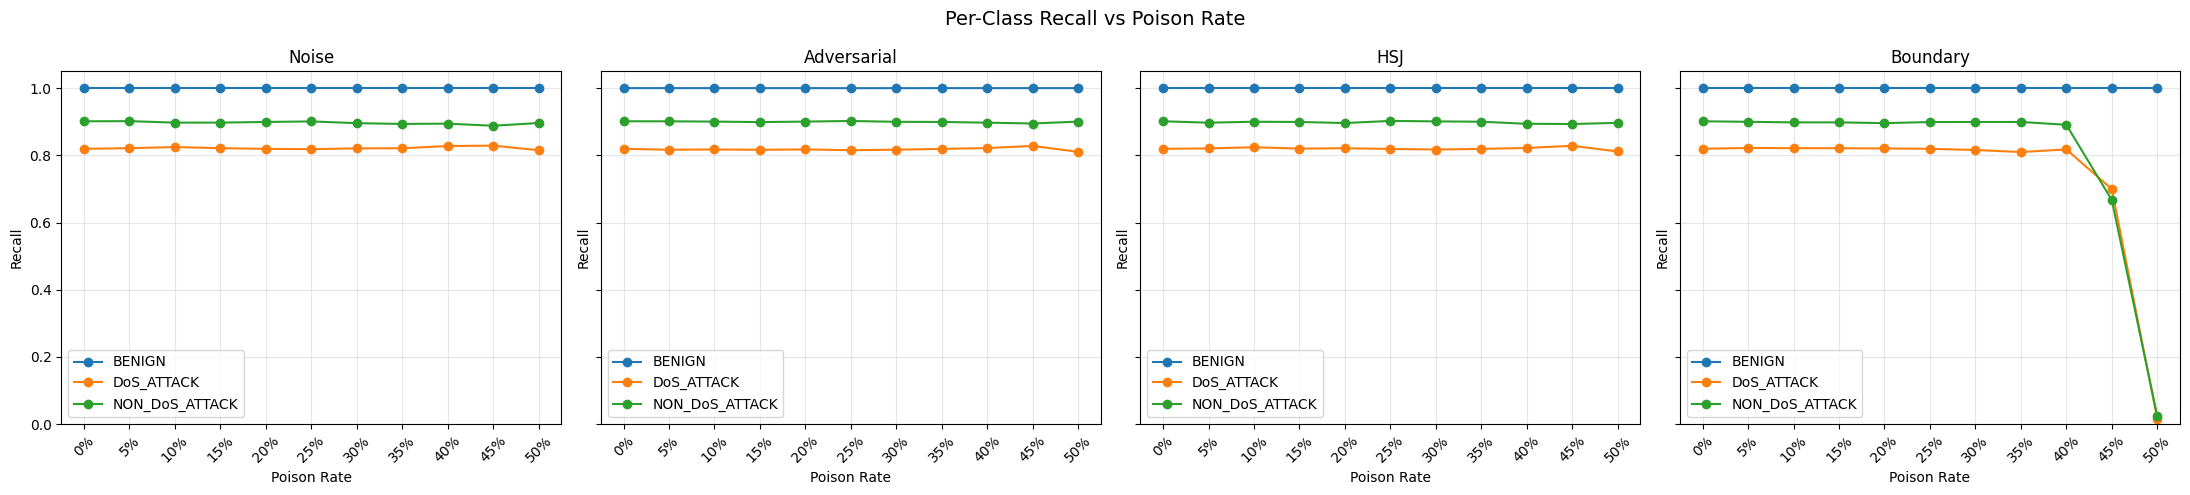

In [28]:
class_names = le.classes_
poison_labels = [f"{int(v*100)}%" for v in GROUPS.values()]
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle("Per-Class Recall vs Poison Rate", fontsize=14)
for ax, source_name in zip(axes, ["Noise", "Adversarial", "HSJ", "Boundary"]):
    per_class_recall = {c: [] for c in class_names}
    for group_name in GROUPS:
        y_pred = group_preds[source_name][group_name]
        for i, cls in enumerate(class_names):
            mask = y_test == i
            if mask.sum() == 0:
                per_class_recall[cls].append(np.nan)
            else:
                per_class_recall[cls].append(np.mean(y_pred[mask] == i))
    for cls in class_names:
        ax.plot(poison_labels, per_class_recall[cls], marker="o", label=cls)
    ax.set_title(source_name)
    ax.set_xlabel("Poison Rate")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()